In [1]:
# Packages
display("text/html", "<style>.container { width:100% !important; }</style>")

using Plots, LaTeXStrings, Distributions, DoubleFloats, Plots.PlotMeasures, LinearAlgebra,
    DataFrames, CSV, LsqFit, StatsBase, Distances, Parameters, Random, StatsBase, Graphs, GraphPlot,
    Base.Threads, Printf, HypothesisTests
# Plots.theme(:dao)

include("../src/wagner_algorithm.jl")
using .BooleanNetwork
include("../src/data_processing.jl")
using .CustomStats
include("../scripts/run_experiments.jl")
using .ExperimentHandler

using ProgressMeter
using Base.Threads: Atomic, atomic_add!
using PyCall

py"""
import sys
import os
sys.path.append(os.path.abspath("../src/"))
from motif_search import *
"""

STANDARD_PARAMETERS = BooleanNetwork.STANDARD_PARAMETERS;

In [2]:
Experiment1Result = ExperimentHandler.Experiment1Result
Experiment2Result = ExperimentHandler.Experiment2Result
MotifStats = ExperimentHandler.MotifStats

Main.ExperimentHandler.MotifStats

In [3]:
# Plotting utilities
const ROOT_DIR = normpath(joinpath(pwd(), ".."))
const FIGURES_DIR = joinpath(ROOT_DIR, "figures")
mkpath(FIGURES_DIR)
const ROBUSTNESS_FIG_DIR = joinpath(FIGURES_DIR, "scatterplots_mutational_robustness")
mkpath(ROBUSTNESS_FIG_DIR)

default(dpi=300, legendfontsize=10, guidefont=font(11), tickfont=font(9), margin=8Plots.mm, grid=false)
const BONFERRONI_TESTS = 2

function save_plot(plot_obj, filename)
    filepath = joinpath(FIGURES_DIR, filename)
    savefig(plot_obj, filepath)
    println("Saved $(filepath)")
end

save_plot (generic function with 1 method)

In [4]:
STANDARD_PARAMETERS["G"] = 200
STANDARD_PARAMETERS["pop_size"] = 20

exp1_config = Experiment1Config(200, 10, "stable", 2, [0.25, 1.0], 5, 30, Gamma(1.0, 1.0))
# generations, pop_size, mode, trials, thetas, robustness_n_mutations, robustness_n_noise_masks, standard_noise

exp1_result = run_experiment1(exp1_config)

base_params = deepcopy(BooleanNetwork.STANDARD_PARAMETERS)
base_params["G"] = exp1_config.generations
base_params["pop_size"] = exp1_config.pop_size
base_params["mode"] = exp1_config.mode

exp2_config = Experiment2Config(3, 5, 30)
# trials, max_loop_size, sample_size
noise_scenarios = build_noise_scenarios(exp1_config)
exp2_result = run_experiment2(exp2_config, base_params, noise_scenarios)


Experiment 1 – noise schedules 100%|█████████████████████| Time: 0:00:06
Random matrices 100%|████████████████████████████████████| Time: 0:00:07
Noiseless evolution 100%|████████████████████████████████| Time: 0:00:05
High-noise evolution 100%|███████████████████████████████| Time: 0:00:11


Main.ExperimentHandler.Experiment2Result(Main.ExperimentHandler.MotifStats(Dict("Incoherent Type 3 (I3)" => [0.12944444444444445, 0.12027777777777779, 0.12555555555555556], "Coherent Type 2 (C2)" => [0.11694444444444445, 0.1340277777777778, 0.1365277777777778], "Incoherent Type 2 (I2)" => [0.12833333333333335, 0.11444444444444443, 0.1166666666666667], "Coherent Type 1 (C1)" => [0.1375, 0.10777777777777779, 0.12777777777777777], "Incoherent Type 4 (I4)" => [0.11000000000000001, 0.15180555555555558, 0.12347222222222223], "Coherent Type 3 (C3)" => [0.11583333333333334, 0.12819444444444444, 0.1276388888888889], "Incoherent Type 1 (I1)" => [0.13722222222222222, 0.11486111111111112, 0.11569444444444446], "Coherent Type 4 (C4)" => [0.12472222222222222, 0.1286111111111111, 0.12666666666666665]), Dict(5 => [0.4977513227513227, 0.49900793650793657, 0.5037698412698411], 4 => [0.49952380952380954, 0.5015873015873016, 0.5058730158730158], 2 => [0.5244444444444445, 0.5288888888888887, 0.522222222222

In [5]:
function add_variance_colorbar!(plt, scenarios, colorscheme)
    if isempty(scenarios)
        return
    end
    min_v = minimum(s.variance for s in scenarios)
    max_v = maximum(s.variance for s in scenarios)
    plot!(
        plt,
        0:1,
        fill(NaN, 2);
        zcolor=[min_v, max_v],
        c=colorscheme,
        label="",
        colorbar=true,
        colorbar_title="Noise Variance " * L"(\theta)",
        grid=false,
        fontsize=12,
        colorbar_titlefont= 12,
        colorbar_width=8,   

    )
end
"""
    plot_metric_many_trials(result::Experiment1Result, metric_key::Symbol;
                            xlabel="Generation", ylabel="", colorscheme=cgrad(:blues),
                            init_gen=1, title="", ci_mult=1.96, outfile=nothing)

Plots `result.averages[metric_key]` with ribbons from `result.sems[metric_key]`.
- Row 1 = baseline scenario (black dotted line)
- Rows 2:end = noisy scenarios, colored by scenario.variance + colorbar
- If `outfile` is provided, saves the plot.
Returns the plot object.
"""
function plot_metric_many_trials(result::Experiment1Result, metric_key::Symbol;
    xlabel::AbstractString="Generation",
    ylabel::AbstractString="",
    colorscheme=cgrad(:blues),
    init_gen::Int=1,
    title::AbstractString="",
    ci_mult::Real=1.96,
    outfile::Union{Nothing,AbstractString}=nothing)

    max_gens = result.config.generations
    scenarios = result.scenarios

    # Fetch metric matrices from dicts
    metric_avgs = result.averages[metric_key]
    metric_sems = result.sems[metric_key]

    gens = init_gen:max_gens

    # Baseline (scenario 1)
    plt = plot(
        1:max_gens,
        metric_avgs[1, 1:max_gens];
        ribbon=metric_sems[1, 1:max_gens],
        color=:black,
        linestyle=:dot,
        linewidth=2,
        label=scenarios[1].label,
        # xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        grid = false,
        xgrid = false,
        ygrid=false,
        minorgrid = false,
        legend=:best,
    )

    # Noisy scenarios (2:end), colored by variance
    noisy_scenarios = scenarios[2:end]
    if !isempty(noisy_scenarios)
        min_var = minimum(s.variance for s in noisy_scenarios)
        max_var = maximum(s.variance for s in noisy_scenarios)
        denom = max(max_var - min_var, eps())

        for (offset, scenario) in enumerate(noisy_scenarios)
            rel_idx = offset + 1
            norm_v = (scenario.variance - min_var) / denom
            line_color = get(colorscheme, clamp(norm_v, 0.0, 1.0))

            plot!(
                plt,
                gens,
                metric_avgs[rel_idx, init_gen:max_gens];
                ribbon=metric_sems[rel_idx, init_gen:max_gens] .* ci_mult,
                color=line_color,
                linewidth=2,
                label=(rel_idx == 2 ? "Noisy" : ""),
                grid = false,
                xgrid=false,
                ygrid=false,
                minorgrid = false,
            )
        end

        add_variance_colorbar!(plt, noisy_scenarios, colorscheme)
    end

    if outfile !== nothing
        save_plot(plt, outfile)
    end

    return plt
end

plot_metric_many_trials

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\fitness_evolution_stable.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\path_evolution_stable.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\completion_evolution_stable.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\alignment_evolution_stable.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\figure_3_combined.png


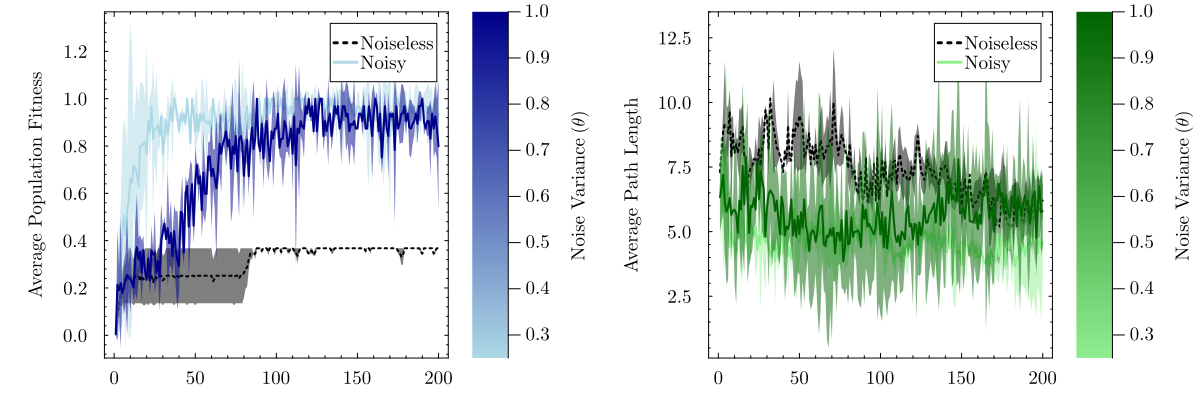

In [6]:
mode_tag = lowercase(replace(exp1_result.config.mode, " " => "_"))

Plots.theme(:dao)

plot_avg_fitness = plot_metric_many_trials(exp1_result, :fit;
    ylabel="Average Population Fitness", outfile="fitness_evolution_$(mode_tag).png", colorscheme = cgrad(:blues))
plot_avg_path = plot_metric_many_trials(exp1_result, :path;
    ylabel="Average Path Length", outfile="path_evolution_$(mode_tag).png", colorscheme = cgrad(:greens))
plot_avg_completion = plot_metric_many_trials(exp1_result, :completion;
    ylabel="Average Completion", outfile="completion_evolution_$(mode_tag).png", colorscheme=cgrad(:Purples_8))
plot_avg_alignment = plot_metric_many_trials(exp1_result, :alignment;
    ylabel="Average Alignment " * L"(A_W)" , outfile="alignment_evolution_$(mode_tag).png", colorscheme=cgrad(:reds))

x_axis = exp1_result.config.generations

# Fitness and Path Length Plot

fig3_combined = plot(plot_avg_fitness, plot_avg_path;
    layout=(1, 2), size=(1200, 400), 
    left_margin=12Plots.mm,
    bottom_margin=5Plots.mm, legendfontsize=12, 
    guidefont = 12, tickfont = 12, colorbar_width=2)

save_plot(fig3_combined, "figure_3_combined.png")
fig3_combined

In [7]:
function alignment_scatter_plot(result::Experiment1Result)
    config = result.config
    noisy_means = vec(mean(result.final_alignments, dims=2))
    noisy_sems = vec(std(result.final_alignments, dims=2) ./ sqrt(config.trials))
    x_vals =[[0]; sqrt.(config.thetas)]

    ci_95 = noisy_sems .* 1.96

    xmin, xmax = extrema(x_vals)
    xpad = (xmax - xmin) * 0.1
    shared_xlims = (xmin - xpad, xmax + xpad)

    top_ylims = (
        minimum(noisy_means .- ci_95) - 0.05,
        maximum(noisy_means .+ ci_95) + 0.05
    )

    p_top = scatter(
        x_vals,
        noisy_means;
        yerror=ci_95,
        color =:brown3,
        ylabel="Average Final Alignment  " * L"\langle A_W \rangle",
        legend=false,
        markersize=8,
        grid=false,
        minorgrid =false,
        ylims=top_ylims,
        xlims=shared_xlims,
        xformatter=_ -> "",
        markerstrokewidth=1,
        errorbarlinewidth=2,
        errorbarcapsize=4,
    )
    p_bottom = plot(
        xlabel="Noise level " * L"(\sigma = \sqrt{\theta})",
        legend=false,
        ylims=(0, .01),
        yticks=[0],
        xlims=shared_xlims,
        grid=false,
        minorgrid=false,
    )

    final_plot = plot(p_top, p_bottom; layout=@layout([a{0.92h}; b{0.08h}]), size=(650, 550))

    save_plot(final_plot, "alignment_regression_broken_axis.png")
    return final_plot
end


alignment_scatter_plot (generic function with 1 method)

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\alignment_regression_broken_axis.png
Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\figure_4_combined.png


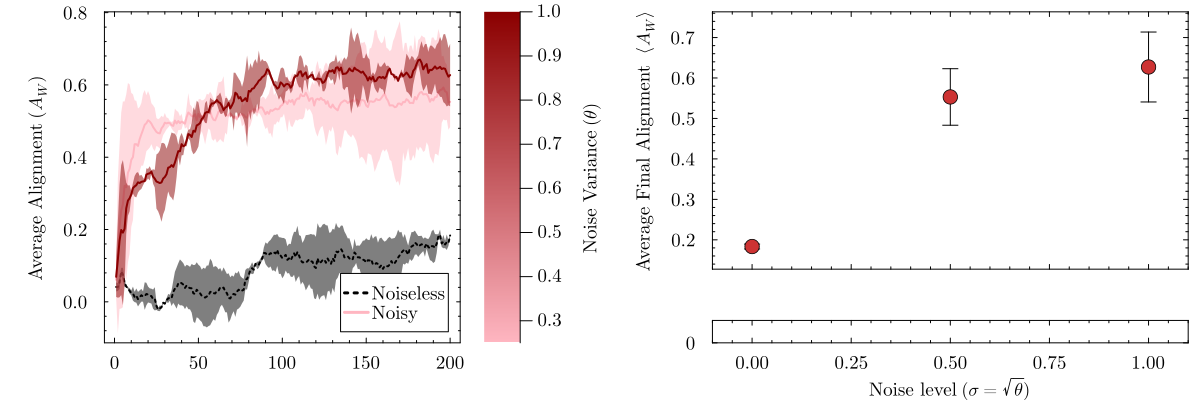

In [8]:
# Alignment plot

scatter_final_alignmet = alignment_scatter_plot(exp1_result)

fig4_combined = plot(plot_avg_alignment, scatter_final_alignmet;
    layout=(1, 2), size=(1200, 400),
    left_margin=12Plots.mm,
    bottom_margin=6Plots.mm, legendfontsize=12, guidefont=12, tickfont=12)

save_plot(fig4_combined, "figure_4_combined.png")
fig4_combined

In [9]:
sanitize_filename(name::String) = replace(lowercase(name), r"[^a-z0-9]+" => "_")

function mutational_scatter_plot(
    xvals,
    yvals;
    xlabel::String,
    ylabel::String,
    title::String,
    xrange::Tuple{Float64,Float64}=(-0.05, 1.05),
    yrange::Tuple{Float64,Float64}=(-0.05, 1.05)
)
    plt = scatter(
        xvals,
        yvals;
        xlabel=xlabel,
        ylabel=ylabel,
        color=:darkorange1,
        title=title,
        label="",
        legend=false,
        markersize=6,
        grid=false, 
        left_margin=12Plots.mm,
        bottom_margin=10Plots.mm,
        xlims=xrange,
        ylims=yrange
    )
    plot!(
        [xrange[1], xrange[2]],
        [yrange[1], yrange[2]];
        color=:black,
        linestyle=:dash,
        left_margin=12Plots.mm,
        bottom_margin=10Plots.mm,
        label="",
        grid=false
    )
    return plt
end

normalize_theta(s::String) = replace(s, "θ" => L"\theta")

function handle_mutational_robustness_scatters(result::Experiment1Result)
    expr_init = result.initial_robustness.mean_expression_shift
    expr_final = result.final_robustness.mean_expression_shift
    stab_init = result.initial_robustness.mean_unstable_shift
    stab_final = result.final_robustness.mean_unstable_shift

    n = length(result.scenarios)
    all_plots = Vector{Any}(undef, n)

    for idx in eachindex(result.scenarios)
        scenario = result.scenarios[idx]
        label_token = sanitize_filename(scenario.label)
        
        x_range_scatter = (minimum(expr_init[idx, :]) - 0.5,
            maximum(expr_init[idx, :]) + 0.5)
        y_range_scatter = (minimum(expr_final[idx, :]) - 0.5,
            maximum(expr_final[idx, :]) + 0.5)

        abs_min = min(x_range_scatter[1], y_range_scatter[1])
        abs_max = max(x_range_scatter[2], y_range_scatter[2])

        lab = normalize_theta(scenario.label)

        expr_plot = mutational_scatter_plot(
            expr_init[idx, :], expr_final[idx, :];
            xlabel="Initial mean expression shift",
            ylabel="Final mean expression shift",
            title="Expression shift  $lab",
            xrange=(abs_min, abs_max),
            yrange=(abs_min, abs_max),
        )

        stab_plot = mutational_scatter_plot(
            stab_init[idx, :], stab_final[idx, :];
            xlabel="Initial mean unstable shift",
            ylabel="Final mean unstable shift",
            title="Stability shift  $lab",
        )

        combined = plot(expr_plot, stab_plot; layout=(1, 2), size=(950, 400), grid=false)
        savefig(combined, joinpath(ROBUSTNESS_FIG_DIR, "robustness_$(label_token).png"))
        all_plots[idx] = combined
    end

    # stack scenarios vertically
    return plot(all_plots...; layout=(n, 1), size=(950, 400n),
            left_margin = 12Plots.mm,bottom_margin=12Plots.mm, )
end

handle_mutational_robustness_scatters (generic function with 1 method)

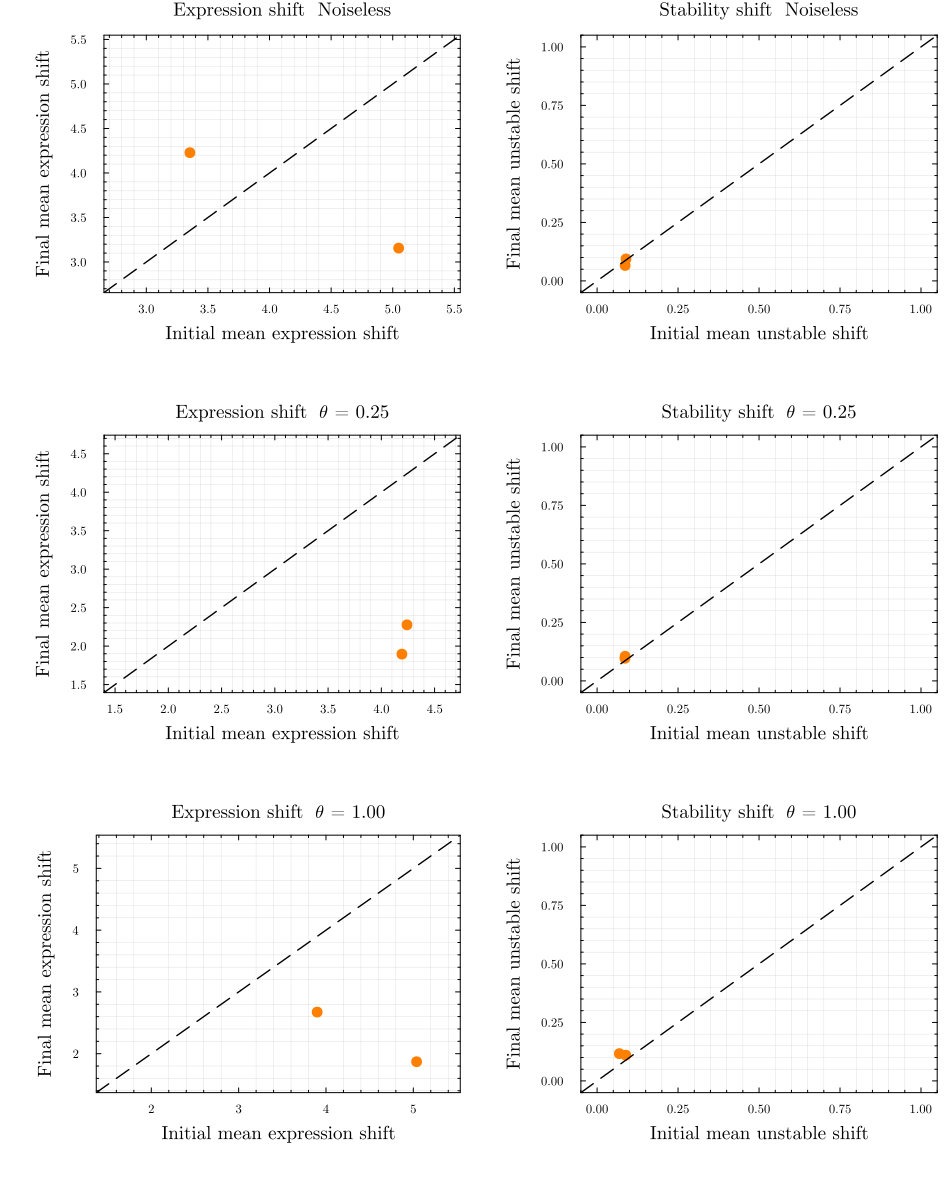

In [10]:
all_plots = handle_mutational_robustness_scatters(exp1_result)


In [11]:
function initial_vs_final_mutational_robustness(result::Experiment1Result)

    expr_init = result.initial_robustness.mean_expression_shift
    expr_final = result.final_robustness.mean_expression_shift
    stab_init = result.initial_robustness.mean_unstable_shift
    stab_final = result.final_robustness.mean_unstable_shift
    theta_vals = [scenario.variance for scenario in result.scenarios]

    expr_change = Float64[]
    expr_ci = Float64[]
    stab_change = Float64[]
    stab_ci = Float64[]

    for idx in eachindex(result.scenarios)
        expr_delta = expr_final[idx, :] .- expr_init[idx, :]
        stab_delta = stab_final[idx, :] .- stab_init[idx, :]

        push!(expr_change, mean(expr_delta))
        push!(stab_change, mean(stab_delta))

        push!(expr_ci, 1.96 * std(expr_delta) / sqrt(length(expr_delta)))
        push!(stab_ci, 1.96 * std(stab_delta) / sqrt(length(stab_delta)))
    end

    x = sqrt.(theta_vals)

    common_kwargs = (
        legend=false,
        grid=false,
        minorgrid=false, marker=:circle,
        color=:darkorange1,
        markersize=7,
        markerstrokewidth=1,

        # error bars (shaft + caps) in PyPlot:
        errorbarlinewidth=2,
        errorbarcapsize=4,
        # keep the series line irrelevant (scatter), but black if used:
        linecolor=:black,

    )

    expr_vs_theta = scatter(
        x, expr_change;
        xlabel="Noise level " * L"(\sigma = \sqrt{\theta})",
        ylabel="Δ mean expression shift",
        yerror=expr_ci,
        common_kwargs...,
    )
    savefig(expr_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "expression_vs_theta.png"))

    stab_vs_theta = scatter(
        x, stab_change;
        xlabel="Noise level " * L"(\sigma = \sqrt{\theta})",
        ylabel="Δ mean instability difference",
        yerror=stab_ci,
        common_kwargs...,
    )
    savefig(stab_vs_theta, joinpath(ROBUSTNESS_FIG_DIR, "stability_vs_theta.png"))

    return expr_vs_theta, stab_vs_theta
end

initial_vs_final_mutational_robustness (generic function with 1 method)

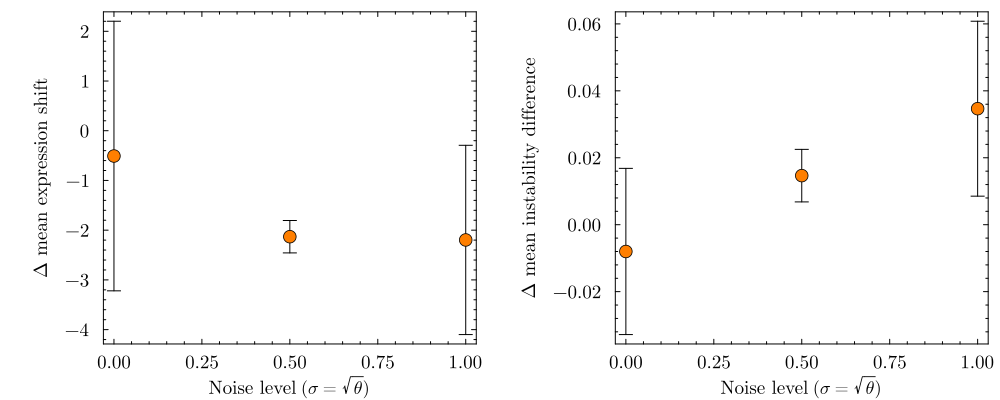

In [12]:
expr_vs_theta, stab_vs_theta = initial_vs_final_mutational_robustness(exp1_result)

plot(expr_vs_theta, stab_vs_theta; 
    layout=(1,2), size =(1000,400),    left_margin=12Plots.mm,
    bottom_margin=5Plots.mm, legendfontsize=12, guidefont = 12, tickfont = 12)


In [13]:
function handle_alignment_tests(result::Experiment1Result; bonferroni_factor::Int=1)
    noiseless = result.final_alignments[1, :]
    noisy = vec(result.final_alignments[2:end, :])
    test = UnequalVarianceTTest(noiseless, noisy)
    println("
Welch's t-test (noiseless vs noisy final alignment)")
    println(test)
    raw_p = pvalue(test)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end
end


handle_alignment_tests (generic function with 1 method)

In [14]:
handle_alignment_tests(exp1_result; bonferroni_factor=BONFERRONI_TESTS)



Welch's t-test (noiseless vs noisy final alignment)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    parameter of interest:   Mean difference
    value under h_0:         0
    point estimate:          -0.406761
    95% confidence interval: (-0.5064, -0.3071)

Test summary:
    outcome with 95% confidence: reject h_0
    two-sided p-value:           0.0009

Details:
    number of observations:   [2,4]
    t-statistic:              -12.851309845929297
    degrees of freedom:       3.0566446980462088
    empirical standard error: 0.031651289760338125

p-value: 0.0009258689870121893
Bonferroni-corrected p-value (x2): 0.0018517379740243785


In [16]:
# Summary helper
function summarize_expectations(data::Dict{K,Vector{Float64}}) where {K}
    return Dict(k => (mean(v), std(v) / sqrt(length(v))) for (k, v) in data)
end

function create_summary_plots(data_dict::Dict{String, Vector{Float64}},
        null_expectation::Dict{String, Tuple{Float64, Float64}}; title::String="",
        data_label::String="Data",null_label::String="Null")
    sorted_keys = sort(collect(keys(data_dict)))
    means = [mean(data_dict[k]) for k in sorted_keys]
    ses = [std(data_dict[k]) / sqrt(length(data_dict[k])) for k in sorted_keys]
    p50_lower = [quantile(data_dict[k], 0.25) for k in sorted_keys]
    p50_upper = [quantile(data_dict[k], 0.75) for k in sorted_keys]
    p95_lower = [quantile(data_dict[k], 0.025) for k in sorted_keys]
    p95_upper = [quantile(data_dict[k], 0.975) for k in sorted_keys]

    null_means = [get(null_expectation, k, (0.0, 0.0))[1] for k in sorted_keys]
    null_ses = [get(null_expectation, k, (0.0, 0.0))[2] for k in sorted_keys]
    colors = [occursin("incoherent", lowercase(k)) ? :red : :blue for k in sorted_keys]
    null_colors = [occursin("incoherent", lowercase(k)) ? :pink : :lightblue2 for k in sorted_keys]

    x_vals = 2 .* 1:(length(sorted_keys) +1)
    δ = 0.30
    x_data = x_vals
    x_null = x_vals .+ δ

    p_left = scatter(
        x_data,
        means;
        xticks=(x_vals, sorted_keys),
        yerror=ses .* 1.96,
        markersize=8,
        markerstrokewidth=1,
        color=colors,
        label=data_label,
        xlabel="FFL Type",
        ylabel="Concentration (%)",
        xrotation=90,
        title=title,
        legend=:topright,
        # background_color_legend=:transparent,
        #grid=:y,
        #gridstyle=:dash,
        grid = false,
        minorgrid = false,
        left_margin=12Plots.mm,
        bottom_margin=10Plots.mm,
        errorbarcolor=:black,
        errorbarlinewidth=2,
        # errorbarcap=:round,
    )
    scatter!(
        x_null,
        null_means;
        xticks=(x_vals, sorted_keys),
        yerror=null_ses .* 1.96,
        marker=:hexagon,
        markersize=6,
        label=null_label,
        color=null_colors,
        # markercolor =null_colors,
        errorbarcolor=null_colors,
        errorbarlinewidth=2,
        errorbarcap=:round,
        markerstrokewidth=0.8,
    )

    ymax = maximum(p95_upper) * 1.1
    p_right = plot(
        xlabel="FFL Type",
        ylabel="Concentration (%)",
        xrotation=90,
        legend=:topright,
        # background_color_legend=:transparent,
        ylim=(0, ymax),
        left_margin=12Plots.mm,
        bottom_margin=12Plots.mm, 
        grid=false,
        minorgrid=false,
    )
    for (idx, key) in enumerate(sorted_keys)
        label95 = idx == 1 ? data_label * " 95% Percentile" : ""
        label50 = idx == 1 ? data_label * " 50% Percentile" : ""
        labelNull = idx == 1 ? null_label * " 95% CI" : ""

        plot!(p_right, [key, key], [p95_lower[idx], p95_upper[idx]]; color=:gray, lw=6, alpha=0.5, label=label95)
        plot!(p_right, [key, key], [p50_lower[idx], p50_upper[idx]]; color=colors[idx], lw=8, alpha=0.8, label=label50)
        plot!(p_right, [key, key], [null_means[idx] - 1.96 * null_ses[idx], null_means[idx] + 1.96 * null_ses[idx]];
            color=:black, lw=2, alpha=0.9, label=labelNull)
        scatter!(p_right, [key], [null_means[idx]]; color=:black, marker=:x, label="")
    end

    # return plot(p_left, p_right; layout=(1, 2), size=(1100, 500))
    return p_left, p_right
end


function create_summary_plots_fbcks(expectations_primary::Dict{Int,Tuple{Float64,Float64}},
    expectations_reference::Dict{Int,Tuple{Float64,Float64}},
    title::String;
    max_size::Int=4,
    color=:blue,
    null_color=:lightblue2,
    reference_label::String="Reference",
    primary_label::String="Primary", 
    null_label::String="Null", data_label::String="Data")

    sizes = 1:max_size
    δ = 0.30

    mean_primary = [get(expectations_primary, s, (NaN, NaN))[1] for s in sizes]
    sem_primary = [get(expectations_primary, s, (NaN, NaN))[2] for s in sizes]
    mean_reference = [get(expectations_reference, s, (NaN, NaN))[1] for s in sizes]
    sem_reference = [get(expectations_reference, s, (NaN, NaN))[2] for s in sizes]

    lower_bounds = min.(mean_primary .- 1.96 .* sem_primary, mean_reference .- 1.96 .* sem_reference)
    upper_bounds = max.(mean_primary .+ 1.96 .* sem_primary, mean_reference .+ 1.96 .* sem_reference)
    global_min = minimum(lower_bounds)
    global_max = maximum(upper_bounds)
    padding = max(0.05, 0.1 * (global_max - global_min))
    ymin = clamp(global_min - padding, 0.0, 1.0)
    ymax = clamp(global_max + padding, 0.0, 1.0)

    plt = plot(
        sizes .+ δ,
        mean_reference;
        yerror=sem_reference .* 1.96,
        seriestype=:scatter,
        marker=:hexagon,
        markersize=6,
        markerstrokewidth=0.8,
        color=null_color,
        label=reference_label,
        xlabel="Loop Size",
        ylabel="Concentration (%)",
        title=title,
        ylim=(ymin, ymax),
        left_margin=10Plots.mm,
        bottom_margin=8Plots.mm,
        legend=:best,
        errorbarcolor=:black,
        errorbarlinewidth=2,
        errorbarcap=:round,
        grid = false,
        minorgrid = false,
    )
    scatter!(
        plt,
        sizes,
        mean_primary;
        yerror=sem_primary .* 1.96,
        marker=:circle,
        markersize=8,
        color=color,
        label=primary_label,
        errorbarcolor=color,
        errorbarlinewidth=2,
        errorbarcap=:round,
        markerstrokewidth=1,
    )
    return plt
end

function handle_noiseless_vs_random(result::Experiment2Result)
    expect_random = summarize_expectations(result.random.ffl)
    expect_noiseless = summarize_expectations(result.noiseless.ffl)

    expect_random_reinf = summarize_expectations(result.random.fbcks_reinf)
    expect_random_balanc = summarize_expectations(result.random.fbcks_balanc)
    expect_noiseless_reinf = summarize_expectations(result.noiseless.fbcks_reinf)
    expect_noiseless_balanc = summarize_expectations(result.noiseless.fbcks_balanc)

    max_size = result.config.max_loop_size

    noiseless_ffl_left, noiseless_ffl_right = create_summary_plots(
        result.noiseless.ffl,
        expect_random;
        null_label="Random",
        data_label="Noiseless"
        # title="Feedforward Loops: Noiseless vs Random"
    )
    noiseless_reinf = create_summary_plots_fbcks(
        expect_noiseless_reinf,
        expect_random_reinf,
        "Positive (Reinforcing) Feedback";
        max_size=max_size,
        color=:blue,
        null_color=:lightblue2,
        reference_label="Random",
        primary_label="Noiseless",
    )
    noiseless_balanc = create_summary_plots_fbcks(
        expect_noiseless_balanc,
        expect_random_balanc,
        "Negative (Balancing) Feedback";
        max_size=max_size,
        color=:red,
        null_color=:pink,
        reference_label="Random",
        primary_label="Noiseless"
    )

    plot_noiseless = plot(noiseless_ffl_left, noiseless_ffl_right, noiseless_reinf, noiseless_balanc; layout = (2,2), size = (1000,800), suptitle = "Random vs Noiseless")
    return plot_noiseless
end

handle_noiseless_vs_random (generic function with 1 method)

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\noiseless_vs_random.png


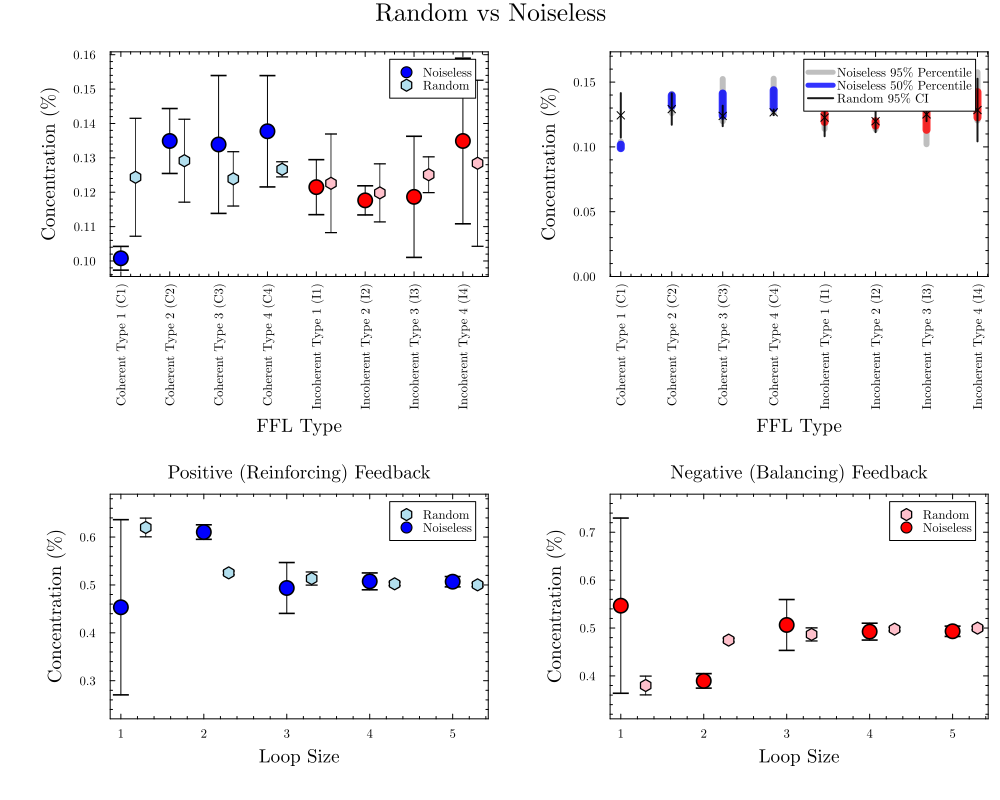

In [17]:
using Logging
Logging.disable_logging(Logging.Warn)
# Warnings at or below the Warning level will be suppressed globally
@warn "You won't see this"

fig5_combined = handle_noiseless_vs_random(exp2_result)
save_plot(fig5_combined, "noiseless_vs_random.png")
fig5_combined

In [18]:
function handle_high_noise_vs_noiseless(result::Experiment2Result)
    expect_noiseless = summarize_expectations(result.noiseless.ffl)
    expect_noisy = summarize_expectations(result.noisy.ffl)

    expect_noiseless_reinf = summarize_expectations(result.noiseless.fbcks_reinf)
    expect_noiseless_balanc = summarize_expectations(result.noiseless.fbcks_balanc)
    expect_noisy_reinf = summarize_expectations(result.noisy.fbcks_reinf)
    expect_noisy_balanc = summarize_expectations(result.noisy.fbcks_balanc)

    max_size = result.config.max_loop_size

    noisy_ffl_left, noisy_ffl_right = create_summary_plots(
        result.noisy.ffl,
        expect_noiseless;
        null_label = "Noiselss",
        data_label = "Very Noisy",
    )
    noisy_reinf = create_summary_plots_fbcks(
        expect_noisy_reinf,
        expect_noiseless_reinf,
        "Reinforcing Feedback";
        max_size=max_size,
        color=:blue,
        null_color=:lightblue2,
        reference_label="Noiseless",
        primary_label="Very Noisy"
    )
    noisy_balanc = create_summary_plots_fbcks(
        expect_noisy_balanc,
        expect_noiseless_balanc,
        "Balancing Feedback";
        max_size=max_size,
        color=:red,
        null_color=:pink,
        reference_label="Noiseless",
        primary_label="Very Noisy"
    )
    # noisy_bottom = plot(noisy_reinf, noisy_balanc; layout=(1, 2), size=(1100, 400))
    # noisy_top = plot(noisy_ffl_left, noisy_ffl_right; layout=(1, 2), size=(1100, 500))
    # plot_noisy = plot(noisy_top, noisy_bottom; layout=(2, 1), size=(1100, 900))
    # save_plot(plot_noisy, "high_noise_vs_noiseless.png")
    combined_plot = plot(noisy_ffl_left, noisy_ffl_right, noisy_reinf, noisy_balanc; layout=(2, 2), size=(1000, 800), suptitle="Very Noisy vs Noiseless")
    return combined_plot
end


handle_high_noise_vs_noiseless (generic function with 1 method)

Saved c:\Users\Kichi\Documents\Documentos_and_Stuff\Academic Projects\SFI GRNs\WagnerNoiseExtension\wagner-noise-extension\figures\high_noise_vs_noiseless.png


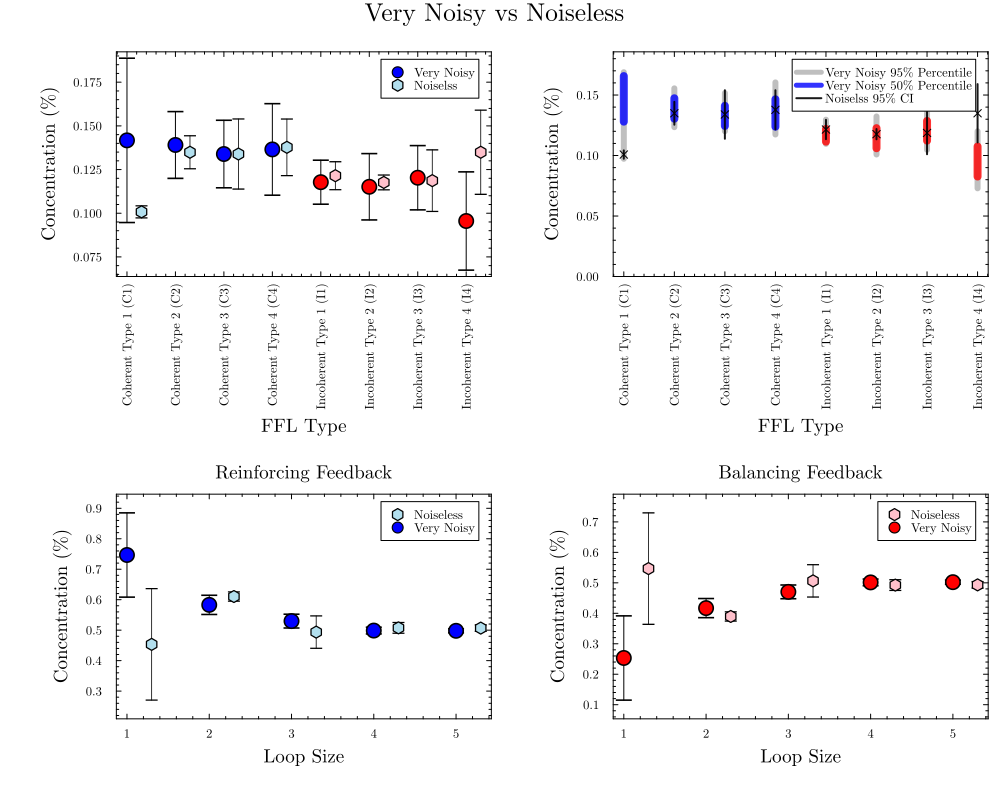

In [19]:
fig6_combined = handle_high_noise_vs_noiseless(exp2_result)
save_plot(fig5_combined, "high_noise_vs_noiseless.png")
fig6_combined

In [20]:
function coherent_fraction_samples(stats::MotifStats)
    if isempty(stats.ffl)
        return zeros(Float64, 0)
    end
    trials = length(first(values(stats.ffl)))
    samples = zeros(Float64, trials)
    for (key, values) in stats.ffl
        if occursin("Coherent", key)
            samples .+= values
        end
    end
    return samples
end

function handle_motif_welch_tests(result::Experiment2Result; bonferroni_factor::Int=1)
    noisy_samples = coherent_fraction_samples(result.noisy)
    noiseless_samples = coherent_fraction_samples(result.noiseless)
    random_samples = coherent_fraction_samples(result.random)

    println("Non-evolved coherence: $(mean(random_samples))")
    println("Noiseless coherence: $(mean(noiseless_samples))")
    println("Noisy coherence: $(mean(noisy_samples))")

    if isempty(noiseless_samples) || isempty(random_samples)
        println("Insufficient motif samples to run Welch's test.")
        return
    end
    test1 = UnequalVarianceTTest(noiseless_samples, random_samples)
    println("
Welch's t-test (noiseless vs random coherent FFL concentration)")
    println(test1)
    raw_p = pvalue(test1)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end

    test2 = UnequalVarianceTTest(noisy_samples, noiseless_samples)
    println("
Welch's t-test (very noisy vs noiseless coherent FFL concentration)")
    println(test2)
    raw_p = pvalue(test2)
    corrected_p = min(raw_p * bonferroni_factor, 1.0)
    println("p-value: $(raw_p)")
    if bonferroni_factor > 1
        println("Bonferroni-corrected p-value (x$(bonferroni_factor)): $(corrected_p)")
    end
end


handle_motif_welch_tests (generic function with 1 method)

In [21]:
handle_motif_welch_tests(exp2_result; bonferroni_factor=BONFERRONI_TESTS)


Non-evolved coherence: 0.5040740740740741
Noiseless coherence: 0.5073148148148148
Noisy coherence: 0.5512037037037036

Welch's t-test (noiseless vs random coherent FFL concentration)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    parameter of interest:   Mean difference
    value under h_0:         0
    point estimate:          0.00324074
    95% confidence interval: (-0.08293, 0.08941)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.9013

Details:
    number of observations:   [3,3]
    t-statistic:              0.13746541005926163
    degrees of freedom:       2.424841529039452
    empirical standard error: 0.0235749541600579

p-value: 0.9012538990124906
Bonferroni-corrected p-value (x2): 1.0

Welch's t-test (very noisy vs noiseless coherent FFL concentration)
Two sample t-test (unequal variance)
------------------------------------
Population details:
    parameter of interest: 